# Surgical Gesture Prediction — Full Pipeline

JIGSAWS kinematics -> next-gesture prediction via behavioral cloning.
Compares BiLSTM, TCN, and Transformer architectures, evaluated with Leave-One-User-Out (LOUO) cross-validation.

## 1. Setup: mount Drive and extract JIGSAWS

Assumes the 4 JIGSAWS zip files (Experimental_setup, Knot_Tying, Needle_Passing, Suturing) are already in your Google Drive root.
See the README for how to request dataset access.

In [1]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_files = {
    "Experimental_setup": "/content/drive/MyDrive/Experimental_setup.zip",
    "Knot_Tying": "/content/drive/MyDrive/Knot_Tying.zip",
    "Needle_Passing": "/content/drive/MyDrive/Needle_Passing.zip",
    "Suturing": "/content/drive/MyDrive/Suturing.zip",
}

extract_root = "/content/jigsaws"
os.makedirs(extract_root, exist_ok=True)

for name, zip_path in zip_files.items():
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(os.path.join(extract_root, name))

print("Extraction done.")


Mounted at /content/drive
Extraction done.


## 2. Load kinematics, transcriptions, and skill metadata

In [2]:
import numpy as np
import re
from pathlib import Path
from collections import Counter

JIGSAWS_ROOT = Path('/content/jigsaws')
TASKS = ['Suturing', 'Knot_Tying', 'Needle_Passing']
SKILL_MAP = {"E": "Expert", "I": "Intermediate", "N": "Novice"}


def get_task_paths(task_name):
    base = JIGSAWS_ROOT / task_name / task_name
    return base / 'kinematics' / 'AllGestures', base / 'transcriptions'


def load_transcription(trans_path):
    intervals = []
    with open(trans_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            intervals.append((int(parts[0]), int(parts[1]), parts[2]))
    return intervals


def load_kinematics(kin_path):
    return np.loadtxt(kin_path)


def build_frame_labels(num_frames, intervals, default_label='NoGesture'):
    labels = np.full(num_frames, default_label, dtype=object)
    for start, end, label in intervals:
        start_idx = max(start - 1, 0)
        end_idx = min(end, num_frames)
        labels[start_idx:end_idx] = label
    return labels


def get_subject(trial_name):
    match = re.search(r'_([A-Z])\d+$', trial_name)
    return match.group(1) if match else None


def load_skill_map(task):
    meta_path = JIGSAWS_ROOT / task / task / f'meta_file_{task}.txt'
    skill_by_trial = {}
    if not meta_path.exists():
        return skill_by_trial
    with open(meta_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            skill_by_trial[parts[0]] = SKILL_MAP.get(parts[1], parts[1])
    return skill_by_trial


def load_all_trials():
    trials = []
    label_counter = Counter()

    for task in TASKS:
        kin_dir, trans_dir = get_task_paths(task)
        skill_by_trial = load_skill_map(task)

        for kin_path in sorted(kin_dir.glob('*.txt')):
            trial_name = kin_path.stem
            trans_path = trans_dir / f'{trial_name}.txt'
            if not trans_path.exists():
                continue

            kin_data = load_kinematics(kin_path)
            intervals = load_transcription(trans_path)
            frame_labels = build_frame_labels(kin_data.shape[0], intervals)
            label_counter.update(frame_labels.tolist())

            trials.append({
                'task': task,
                'trial_name': trial_name,
                'subject': get_subject(trial_name),
                'skill': skill_by_trial.get(trial_name, 'Unknown'),
                'kinematics_raw': kin_data.astype(np.float32),
                'labels': frame_labels,
            })

    return trials, label_counter


trials, label_counter = load_all_trials()
ALL_LABELS = sorted(label_counter.keys())
label_to_idx = {label: i for i, label in enumerate(ALL_LABELS)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
NUM_CLASSES = len(ALL_LABELS)

print(f"Loaded {len(trials)} trials, {NUM_CLASSES} gesture classes.")
print("Gesture distribution:", dict(label_counter))


Loaded 103 trials, 15 gesture classes.
Gesture distribution: {'NoGesture': 10929, 'G1': 7091, 'G5': 8250, 'G8': 15587, 'G2': 52655, 'G3': 54731, 'G6': 39355, 'G4': 24620, 'G11': 15913, 'G9': 2425, 'G10': 1634, 'G12': 13031, 'G13': 7690, 'G14': 12658, 'G15': 17741}


## 3. Sliding-window dataset

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader


class GestureSequenceDataset(Dataset):
    """Builds fixed-length kinematic windows and predicts the gesture of the frame right after each window."""

    def __init__(self, trial_list, trial_ids, feature_mean, feature_std, window_size=30, stride=5):
        self.window_size = window_size
        self.samples = []
        self.kinematics_list = []
        self.labels_list = []

        for local_idx, trial_id in enumerate(trial_ids):
            trial = trial_list[trial_id]
            kin = ((trial['kinematics_raw'] - feature_mean) / feature_std).astype(np.float32)
            labels = np.array([label_to_idx[l] for l in trial['labels']], dtype=np.int64)

            self.kinematics_list.append(kin)
            self.labels_list.append(labels)

            num_frames = kin.shape[0]
            last_start = num_frames - window_size - 1
            for start in range(0, max(last_start, 0) + 1, stride):
                self.samples.append((local_idx, start))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        local_idx, start = self.samples[idx]
        kin = self.kinematics_list[local_idx]
        labels = self.labels_list[local_idx]
        window = kin[start:start + self.window_size]
        target = labels[start + self.window_size]
        return torch.from_numpy(window), torch.tensor(target)


## 4. Model architectures: BiLSTM, TCN, Transformer

In [4]:
import math
import torch.nn as nn


class BiLSTMGesturePolicy(nn.Module):
    def __init__(self, input_dim=76, hidden_dim=128, num_layers=2, num_classes=15, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                             bidirectional=True, dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])


class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.3):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.chomp_size = padding
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def _chomp(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x

    def forward(self, x):
        out = self.relu(self._chomp(self.conv1(x)))
        out = self.dropout(out)
        out = self.relu(self._chomp(self.conv2(out)))
        out = self.dropout(out)
        residual = x if self.downsample is None else self.downsample(x)
        return self.relu(out + residual)


class TCNGesturePolicy(nn.Module):
    def __init__(self, input_dim=76, num_channels=(64, 128, 128), kernel_size=3, num_classes=15, dropout=0.3):
        super().__init__()
        layers = []
        in_ch = input_dim
        for i, out_ch in enumerate(num_channels):
            layers.append(TCNBlock(in_ch, out_ch, kernel_size, 2 ** i, dropout))
            in_ch = out_ch
        self.tcn = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Linear(num_channels[-1], 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        out = self.tcn(x)
        return self.classifier(out[:, :, -1])


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerGesturePolicy(nn.Module):
    def __init__(self, input_dim=76, d_model=128, nhead=4, num_layers=3, num_classes=15, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, d_model * 4, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.pos_encoding(self.input_proj(x))
        out = self.transformer_encoder(x)
        return self.classifier(out[:, -1, :])


MODEL_BUILDERS = {
    "BiLSTM": lambda: BiLSTMGesturePolicy(input_dim=76, hidden_dim=128, num_layers=2, num_classes=NUM_CLASSES, dropout=0.3),
    "TCN": lambda: TCNGesturePolicy(input_dim=76, num_channels=(64, 128, 128), kernel_size=3, num_classes=NUM_CLASSES, dropout=0.3),
    "Transformer": lambda: TransformerGesturePolicy(input_dim=76, d_model=128, nhead=4, num_layers=3, num_classes=NUM_CLASSES, dropout=0.3),
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 5. Train/eval helpers

In [22]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x_batch.size(0)
            total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total_samples += x_batch.size(0)
    return total_loss / total_samples, total_correct / total_samples


def train_one_fold(model_name, train_ids, val_ids, test_ids, num_epochs=10, lr=1e-3, weight_decay=1e-4):
    train_kin_concat = np.concatenate([trials[i]['kinematics_raw'] for i in train_ids], axis=0)
    fmean = train_kin_concat.mean(axis=0)
    fstd = train_kin_concat.std(axis=0) + 1e-8

    train_ds = GestureSequenceDataset(trials, train_ids, fmean, fstd, window_size=30, stride=5)
    val_ds = GestureSequenceDataset(trials, val_ids, fmean, fstd, window_size=30, stride=5)
    test_ds = GestureSequenceDataset(trials, test_ids, fmean, fstd, window_size=30, stride=5)

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)

    model = MODEL_BUILDERS[model_name]().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, num_epochs + 1):
        run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None)
    return test_acc, test_loss, model


## 6. Leave-One-User-Out (LOUO) cross-validation

Each surgeon is held out once as the test set; all three architectures are compared under the same protocol.
This is the scientifically rigorous evaluation (see README for why it matters vs. a random split).

In [6]:
from collections import defaultdict
import time

for t in trials:
    if t['subject'] is None:
        t['subject'] = get_subject(t['trial_name'])
subjects = sorted(set(t['subject'] for t in trials))

NUM_EPOCHS_PER_FOLD = 10
results = defaultdict(list)

for subject in subjects:
    test_ids = [i for i, t in enumerate(trials) if t['subject'] == subject]
    remaining_ids = [i for i, t in enumerate(trials) if t['subject'] != subject]

    np.random.seed(42)
    shuffled = np.random.permutation(remaining_ids)
    val_cut = max(1, int(0.15 * len(shuffled)))
    val_ids = shuffled[:val_cut].tolist()
    train_ids = shuffled[val_cut:].tolist()

    for model_name in MODEL_BUILDERS:
        start = time.time()
        test_acc, test_loss, _ = train_one_fold(model_name, train_ids, val_ids, test_ids, num_epochs=NUM_EPOCHS_PER_FOLD)
        elapsed = time.time() - start
        results[model_name].append((subject, test_acc, test_loss))
        print(f"[{model_name}] subject={subject} test_acc={test_acc:.4f} test_loss={test_loss:.4f} ({elapsed:.1f}s)")

summary = {}
for model_name, fold_results in results.items():
    accs = [r[1] for r in fold_results]
    summary[model_name] = {"mean_acc": float(np.mean(accs)), "std_acc": float(np.std(accs))}

print("\nLOUO summary:")
for name, s in summary.items():
    print(f"  {name}: {s['mean_acc']:.4f} +/- {s['std_acc']:.4f}")


[BiLSTM] subject=B test_acc=0.4168 test_loss=2.5516 (58.1s)
[TCN] subject=B test_acc=0.4807 test_loss=2.1809 (60.2s)
[Transformer] subject=B test_acc=0.4452 test_loss=2.6608 (90.1s)
[BiLSTM] subject=C test_acc=0.6906 test_loss=1.0902 (55.0s)
[TCN] subject=C test_acc=0.6245 test_loss=1.1645 (58.4s)
[Transformer] subject=C test_acc=0.6004 test_loss=1.2629 (87.2s)
[BiLSTM] subject=D test_acc=0.4988 test_loss=2.3255 (55.5s)
[TCN] subject=D test_acc=0.5244 test_loss=2.0516 (59.8s)
[Transformer] subject=D test_acc=0.5636 test_loss=2.2681 (87.9s)
[BiLSTM] subject=E test_acc=0.6277 test_loss=1.2907 (56.0s)
[TCN] subject=E test_acc=0.5951 test_loss=2.2628 (61.9s)
[Transformer] subject=E test_acc=0.6637 test_loss=1.0324 (89.9s)
[BiLSTM] subject=F test_acc=0.6412 test_loss=1.7580 (57.7s)
[TCN] subject=F test_acc=0.6588 test_loss=1.7983 (62.5s)
[Transformer] subject=F test_acc=0.6042 test_loss=1.8563 (93.1s)
[BiLSTM] subject=G test_acc=0.4209 test_loss=2.5879 (56.8s)
[TCN] subject=G test_acc=0.488

## 7. Error analysis on the best model (Transformer)

Aggregates predictions across all LOUO folds into one confusion matrix, plus accuracy broken down by surgeon skill level.

In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

class GestureSequenceDatasetWithTrialId(GestureSequenceDataset):
    def __init__(self, trial_list, trial_ids, feature_mean, feature_std, window_size=30, stride=5):
        super().__init__(trial_list, trial_ids, feature_mean, feature_std, window_size, stride)
        self.trial_id_per_local = trial_ids

    def __getitem__(self, idx):
        local_idx, start = self.samples[idx]
        window, target = super().__getitem__(idx)
        return window, target, self.trial_id_per_local[local_idx]


def run_epoch_eval_with_ids(model, loader, criterion):
    model.eval()
    all_true, all_pred, all_trial_ids = [], [], []
    with torch.no_grad():
        for x_batch, y_batch, trial_ids in loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(x_batch)
            preds = logits.argmax(dim=1)
            all_true.extend(y_batch.cpu().tolist())
            all_pred.extend(preds.cpu().tolist())
            all_trial_ids.extend(trial_ids.tolist() if torch.is_tensor(trial_ids) else trial_ids)
    return all_true, all_pred, all_trial_ids


all_y_true, all_y_pred, all_trial_ids_flat = [], [], []

for subject in subjects:
    test_ids = [i for i, t in enumerate(trials) if t['subject'] == subject]
    remaining_ids = [i for i, t in enumerate(trials) if t['subject'] != subject]

    np.random.seed(42)
    shuffled = np.random.permutation(remaining_ids)
    val_cut = max(1, int(0.15 * len(shuffled)))
    val_ids = shuffled[:val_cut].tolist()
    train_ids = shuffled[val_cut:].tolist()

    train_kin_concat = np.concatenate([trials[i]['kinematics_raw'] for i in train_ids], axis=0)
    fmean = train_kin_concat.mean(axis=0)
    fstd = train_kin_concat.std(axis=0) + 1e-8

    _, _, model = train_one_fold("Transformer", train_ids, val_ids, test_ids, num_epochs=NUM_EPOCHS_PER_FOLD)

    test_ds = GestureSequenceDatasetWithTrialId(trials, test_ids, fmean, fstd, window_size=30, stride=5)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)
    y_true, y_pred, trial_ids_flat = run_epoch_eval_with_ids(model, test_loader, nn.CrossEntropyLoss())

    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)
    all_trial_ids_flat.extend(trial_ids_flat)

print(f"Aggregate LOUO accuracy: {np.mean(np.array(all_y_true) == np.array(all_y_pred)):.4f}")

present_labels = sorted(set(all_y_true) | set(all_y_pred))
label_names = [idx_to_label[i] for i in present_labels]
print(classification_report(all_y_true, all_y_pred, labels=present_labels, target_names=label_names, zero_division=0))


Aggregate LOUO accuracy: 0.5732
              precision    recall  f1-score   support

          G1       0.44      0.44      0.44      1271
         G10       0.00      0.00      0.00       327
         G11       0.46      0.48      0.47      3172
         G12       0.37      0.33      0.35      2572
         G13       0.44      0.46      0.45      1541
         G14       0.56      0.49      0.52      2525
         G15       0.51      0.73      0.60      3552
          G2       0.65      0.61      0.63     10527
          G3       0.76      0.74      0.75     10957
          G4       0.59      0.58      0.58      4925
          G5       0.42      0.37      0.39      1594
          G6       0.60      0.63      0.61      7865
          G8       0.30      0.30      0.30      3105
          G9       0.03      0.01      0.01       485
   NoGesture       0.43      0.50      0.46      1868

    accuracy                           0.57     56286
   macro avg       0.44      0.44      0.44     

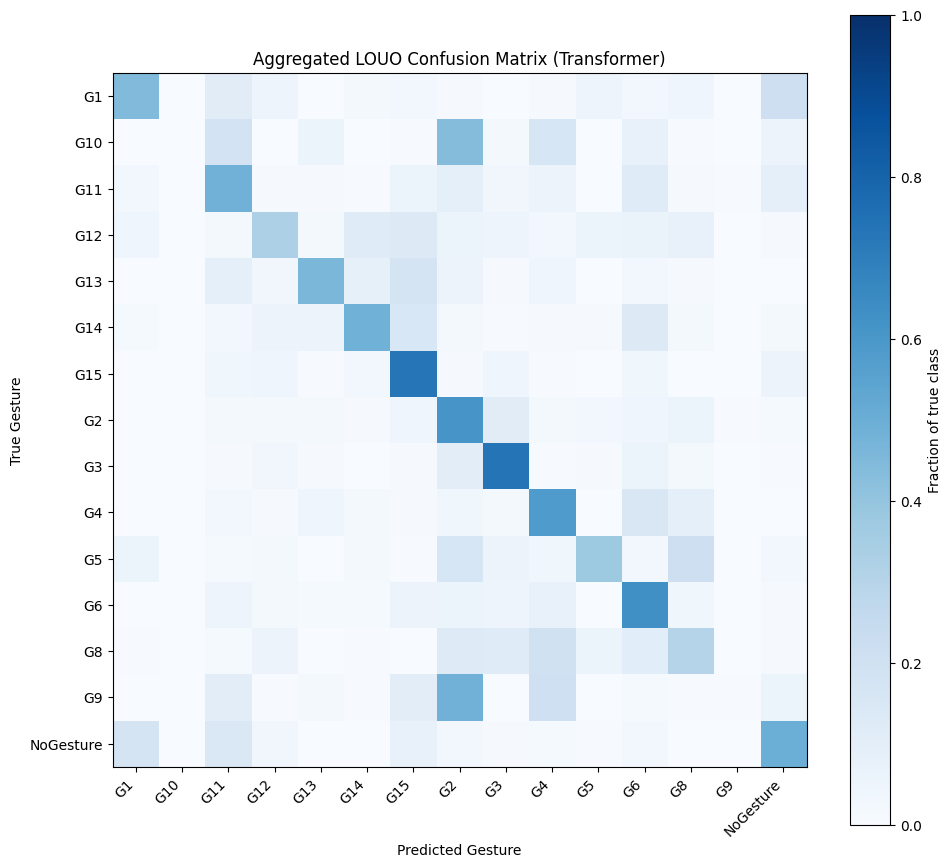

In [8]:
cm = confusion_matrix(all_y_true, all_y_pred, labels=present_labels)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted Gesture")
ax.set_ylabel("True Gesture")
ax.set_title("Aggregated LOUO Confusion Matrix (Transformer)")
fig.colorbar(im, ax=ax, label="Fraction of true class")
fig.tight_layout()
fig.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


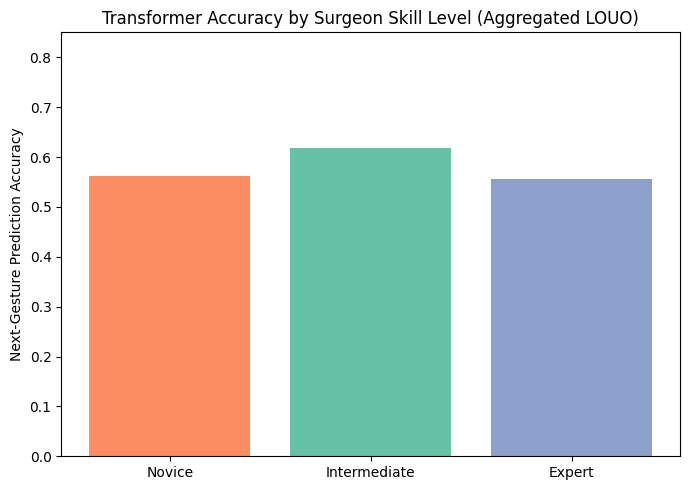

Novice: 0.5623
Intermediate: 0.6175
Expert: 0.5566


In [9]:
from collections import defaultdict as dd

skill_per_sample = [trials[tid]['skill'] for tid in all_trial_ids_flat]
skill_accuracy = dd(lambda: [0, 0])
for true_l, pred_l, skill in zip(all_y_true, all_y_pred, skill_per_sample):
    skill_accuracy[skill][1] += 1
    if true_l == pred_l:
        skill_accuracy[skill][0] += 1

skill_order = [s for s in ["Novice", "Intermediate", "Expert"] if s in skill_accuracy]
accs = [skill_accuracy[s][0] / skill_accuracy[s][1] for s in skill_order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(skill_order, accs, color=["#fc8d62", "#66c2a5", "#8da0cb"][:len(skill_order)])
ax.set_ylabel("Next-Gesture Prediction Accuracy")
ax.set_title("Transformer Accuracy by Surgeon Skill Level (Aggregated LOUO)")
ax.set_ylim(0, 0.85)
fig.tight_layout()
fig.savefig("/content/skill_level_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

for s, acc in zip(skill_order, accs):
    print(f"{s}: {acc:.4f}")


## 8. Final model: train on the full dataset

Separate from the LOUO evaluation numbers above (which measure generalization to unseen surgeons), this final model uses all available data for the best real-world / demo performance.

In [10]:
from sklearn.model_selection import train_test_split

trial_indices = list(range(len(trials)))
trial_tasks = [t['task'] for t in trials]
train_idx, val_idx = train_test_split(trial_indices, test_size=0.15, random_state=42, stratify=trial_tasks)

train_kin_concat = np.concatenate([trials[i]['kinematics_raw'] for i in train_idx], axis=0)
final_feature_mean = train_kin_concat.mean(axis=0)
final_feature_std = train_kin_concat.std(axis=0) + 1e-8

final_train_ds = GestureSequenceDataset(trials, train_idx, final_feature_mean, final_feature_std)
final_val_ds = GestureSequenceDataset(trials, val_idx, final_feature_mean, final_feature_std)
final_train_loader = DataLoader(final_train_ds, batch_size=64, shuffle=True, num_workers=2)
final_val_loader = DataLoader(final_val_ds, batch_size=64, shuffle=False, num_workers=2)

final_model = TransformerGesturePolicy(input_dim=76, d_model=128, nhead=4, num_layers=3,
                                        num_classes=NUM_CLASSES, dropout=0.3).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_loss = float("inf")
best_state = None

for epoch in range(1, 11):
    run_epoch(final_model, final_train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(final_model, final_val_loader, criterion, optimizer=None)
    print(f"Epoch {epoch}/10 | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in final_model.state_dict().items()}

final_model.load_state_dict(best_state)

torch.save({
    "model_state_dict": final_model.state_dict(),
    "feature_mean": final_feature_mean,
    "feature_std": final_feature_std,
    "label_to_idx": label_to_idx,
    "idx_to_label": idx_to_label,
}, "/content/final_transformer_model.pt")

print("Saved final_transformer_model.pt")


Epoch 1/10 | val_loss=1.3693 val_acc=0.6957
Epoch 2/10 | val_loss=1.3764 val_acc=0.7074
Epoch 3/10 | val_loss=1.5528 val_acc=0.7161
Epoch 4/10 | val_loss=1.5759 val_acc=0.7141
Epoch 5/10 | val_loss=1.7856 val_acc=0.7152
Epoch 6/10 | val_loss=1.7255 val_acc=0.6949
Epoch 7/10 | val_loss=1.5635 val_acc=0.7369
Epoch 8/10 | val_loss=1.6695 val_acc=0.7019
Epoch 9/10 | val_loss=1.8548 val_acc=0.7159
Epoch 10/10 | val_loss=1.9076 val_acc=0.7134
Saved final_transformer_model.pt


## 8.5 Trajectory prediction (motion-level extension)

A complementary, finer-grained model: predicts the next 5 frames (~160ms) of all 76 kinematic features from the same 30-frame window, instead of the next gesture label.

Design choices (each one fixed a real problem found during development, not just a default):
- **Delta prediction** (change from the last observed frame, not an absolute value) — an earlier absolute-value version was quantitatively worse than a naive "repeat last frame" baseline.
- **Direct multi-horizon output** (all 5 future frames in a single forward pass, not autoregressive) — avoids compounding error across the horizon.
- **Weighted Huber loss** (near-term frames weighted more, robust to outliers) — more appropriate than plain MSE given sudden surgical movements.

In [21]:
class TrajectoryDeltaDataset(Dataset):
    """Predicts the DELTA (change) from the last observed frame, not the absolute future value."""

    def __init__(self, trial_list, trial_ids, feature_mean, feature_std, window_size=30, horizon=5, stride=5):
        self.window_size = window_size
        self.horizon = horizon
        self.samples = []
        self.kinematics_list = []

        for local_idx, trial_id in enumerate(trial_ids):
            trial = trial_list[trial_id]
            kin = ((trial['kinematics_raw'] - feature_mean) / feature_std).astype(np.float32)
            self.kinematics_list.append(kin)

            num_frames = kin.shape[0]
            last_start = num_frames - window_size - horizon
            for start in range(0, max(last_start, 0) + 1, stride):
                self.samples.append((local_idx, start))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        local_idx, start = self.samples[idx]
        kin = self.kinematics_list[local_idx]
        window = kin[start:start + self.window_size]
        last_frame = window[-1]
        future_abs = kin[start + self.window_size:start + self.window_size + self.horizon]
        future_delta = future_abs - last_frame[None, :]
        return torch.from_numpy(window), torch.from_numpy(future_delta), torch.from_numpy(last_frame)


class TransformerDeltaPolicy(nn.Module):
    """Directly predicts all `horizon` future delta frames in a single forward pass
    (multi-horizon direct prediction, NOT autoregressive) -- this is what avoids
    error accumulation across the prediction horizon."""

    def __init__(self, input_dim=76, d_model=128, nhead=4, num_layers=3, horizon=5, dropout=0.3):
        super().__init__()
        self.horizon = horizon
        self.input_dim = input_dim
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, d_model * 4, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.regressor = nn.Sequential(
            nn.Linear(d_model, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, horizon * input_dim)
        )

    def forward(self, x):
        x = self.pos_encoding(self.input_proj(x))
        out = self.transformer_encoder(x)
        last_step = out[:, -1, :]
        pred_delta = self.regressor(last_step)
        return pred_delta.view(-1, self.horizon, self.input_dim)


class WeightedHuberLoss(nn.Module):
    """Huber loss (robust to outliers like sudden surgical movements),
    still weighted so near-term horizon steps matter more than far ones."""

    def __init__(self, horizon, device, delta=1.0):
        super().__init__()
        weights = torch.linspace(1.0, 0.3, horizon).to(device)
        self.weights = weights.view(1, horizon, 1)
        self.huber = nn.HuberLoss(delta=delta, reduction='none')

    def forward(self, pred, target):
        per_element_loss = self.huber(pred, target)
        return (per_element_loss * self.weights).mean()


In [20]:
TRAJ_WINDOW_SIZE = 30
TRAJ_HORIZON = 5

traj_train_kin = np.concatenate([trials[i]['kinematics_raw'] for i in train_idx], axis=0)
traj_feature_mean = traj_train_kin.mean(axis=0)
traj_feature_std = traj_train_kin.std(axis=0) + 1e-8

traj_train_ds = TrajectoryDeltaDataset(trials, train_idx, traj_feature_mean, traj_feature_std, TRAJ_WINDOW_SIZE, TRAJ_HORIZON)
traj_val_ds = TrajectoryDeltaDataset(trials, val_idx, traj_feature_mean, traj_feature_std, TRAJ_WINDOW_SIZE, TRAJ_HORIZON)
traj_train_loader = DataLoader(traj_train_ds, batch_size=64, shuffle=True, num_workers=2)
traj_val_loader = DataLoader(traj_val_ds, batch_size=64, shuffle=False, num_workers=2)

print(f"Train samples: {len(traj_train_ds)}, val samples: {len(traj_val_ds)}")

traj_model = TransformerDeltaPolicy(input_dim=76, d_model=128, nhead=4, num_layers=3,
                                     horizon=TRAJ_HORIZON, dropout=0.3).to(DEVICE)
traj_criterion = WeightedHuberLoss(horizon=TRAJ_HORIZON, device=DEVICE, delta=1.0)
traj_optimizer = torch.optim.Adam(traj_model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_loss = float("inf")
best_state = None

for epoch in range(1, 16):
    traj_model.train()
    train_loss_total, train_n = 0.0, 0
    for x_batch, y_delta, _ in traj_train_loader:
        x_batch, y_delta = x_batch.to(DEVICE), y_delta.to(DEVICE)
        pred_delta = traj_model(x_batch)
        loss = traj_criterion(pred_delta, y_delta)
        traj_optimizer.zero_grad()
        loss.backward()
        traj_optimizer.step()
        train_loss_total += loss.item() * x_batch.size(0)
        train_n += x_batch.size(0)
    train_loss = train_loss_total / train_n

    traj_model.eval()
    val_loss_total, val_n = 0.0, 0
    with torch.no_grad():
        for x_batch, y_delta, _ in traj_val_loader:
            x_batch, y_delta = x_batch.to(DEVICE), y_delta.to(DEVICE)
            pred_delta = traj_model(x_batch)
            loss = traj_criterion(pred_delta, y_delta)
            val_loss_total += loss.item() * x_batch.size(0)
            val_n += x_batch.size(0)
    val_loss = val_loss_total / val_n

    print(f"Epoch {epoch}/15 | train_huber={train_loss:.5f} val_huber={val_loss:.5f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in traj_model.state_dict().items()}

traj_model.load_state_dict(best_state)

torch.save({
    "model_state_dict": traj_model.state_dict(),
    "feature_mean": traj_feature_mean,
    "feature_std": traj_feature_std,
    "window_size": TRAJ_WINDOW_SIZE,
    "horizon": TRAJ_HORIZON,
}, "/content/trajectory_transformer_model_v4_huber.pt")

print("Saved trajectory_transformer_model_v4_huber.pt")


Train samples: 47872, val samples: 8332
Epoch 1/15 | train_huber=0.04301 val_huber=0.04110
Epoch 2/15 | train_huber=0.03843 val_huber=0.03939
Epoch 3/15 | train_huber=0.03783 val_huber=0.03919
Epoch 4/15 | train_huber=0.03768 val_huber=0.03903
Epoch 5/15 | train_huber=0.03758 val_huber=0.03909
Epoch 6/15 | train_huber=0.03748 val_huber=0.03870
Epoch 7/15 | train_huber=0.03733 val_huber=0.03865
Epoch 8/15 | train_huber=0.03726 val_huber=0.03863
Epoch 9/15 | train_huber=0.03724 val_huber=0.03851
Epoch 10/15 | train_huber=0.03714 val_huber=0.03844
Epoch 11/15 | train_huber=0.03701 val_huber=0.03811
Epoch 12/15 | train_huber=0.03689 val_huber=0.03803
Epoch 13/15 | train_huber=0.03689 val_huber=0.03812
Epoch 14/15 | train_huber=0.03685 val_huber=0.03802
Epoch 15/15 | train_huber=0.03682 val_huber=0.03808
Saved trajectory_transformer_model_v4_huber.pt


### Evaluation: naive baseline, per-feature-group breakdown, and statistical significance

In [19]:
from scipy import stats

MANIPULATOR_NAMES = ["left_master", "right_master", "left_slave", "right_slave"]
FEATURE_GROUPS_PER_MANIPULATOR = {
    "position": list(range(0, 3)),
    "rotation": list(range(3, 12)),
    "linear_velocity": list(range(12, 15)),
    "angular_velocity": list(range(15, 18)),
    "gripper_angle": [18],
}

feature_to_group = {}
for m_idx, m_name in enumerate(MANIPULATOR_NAMES):
    offset = m_idx * 19
    for group_name, local_idxs in FEATURE_GROUPS_PER_MANIPULATOR.items():
        for li in local_idxs:
            feature_to_group[offset + li] = group_name

group_names = list(FEATURE_GROUPS_PER_MANIPULATOR.keys())
group_to_indices = {g: [i for i, gn in feature_to_group.items() if gn == g] for g in group_names}

traj_model.eval()
n_samples_to_check = 500
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(traj_val_ds), size=min(n_samples_to_check, len(traj_val_ds)), replace=False)

model_sample_mae = []
baseline_sample_mae = []
model_feature_errors = []

with torch.no_grad():
    for idx in sample_indices:
        window, delta_target, last_frame = traj_val_ds[idx]
        x = window.unsqueeze(0).to(DEVICE)
        pred_delta = traj_model(x).cpu().numpy()[0]

        pred_abs = last_frame.numpy()[None, :] + pred_delta
        target_abs = last_frame.numpy()[None, :] + delta_target.numpy()

        abs_err = np.abs(pred_abs - target_abs)
        model_feature_errors.append(abs_err)
        model_sample_mae.append(abs_err.mean())

        naive_err = np.abs(last_frame.numpy()[None, :] - target_abs)
        baseline_sample_mae.append(naive_err.mean())

model_sample_mae = np.array(model_sample_mae)
baseline_sample_mae = np.array(baseline_sample_mae)
model_feature_errors = np.array(model_feature_errors)

print("MAE by feature group (averaged over horizon and samples):")
for group in group_names:
    idxs = group_to_indices[group]
    group_mae = model_feature_errors[:, :, idxs].mean()
    print(f"  {group:18s}: {group_mae:.4f}  ({len(idxs)} features)")

diffs = baseline_sample_mae - model_sample_mae
t_stat, p_value_ttest = stats.ttest_rel(baseline_sample_mae, model_sample_mae)
w_stat, p_value_wilcoxon = stats.wilcoxon(baseline_sample_mae, model_sample_mae)
mean_diff = diffs.mean()
sem_diff = diffs.std(ddof=1) / np.sqrt(len(diffs))
ci_95 = (mean_diff - 1.96 * sem_diff, mean_diff + 1.96 * sem_diff)

print(f"\nPaired comparison over {len(sample_indices)} validation windows:")
print(f"  Mean MAE reduction (baseline - model): {mean_diff:.4f}")
print(f"  95% CI: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]")
print(f"  Paired t-test: t={t_stat:.2f}, p={p_value_ttest:.2e}")
print(f"  Wilcoxon signed-rank: W={w_stat:.2f}, p={p_value_wilcoxon:.2e}")
print(f"  Model better on {(diffs > 0).sum()}/{len(diffs)} windows ({(diffs > 0).mean():.1%})")


MAE by feature group (averaged over horizon and samples):
  position          : 0.0265  (12 features)
  rotation          : 0.0364  (36 features)
  linear_velocity   : 0.3425  (12 features)
  angular_velocity  : 0.4114  (12 features)
  gripper_angle     : 0.0644  (4 features)

Paired comparison over 500 validation windows:
  Mean MAE reduction (baseline - model): 0.0147
  95% CI: [0.0117, 0.0177]
  Paired t-test: t=9.59, p=4.15e-20
  Wilcoxon signed-rank: W=38315.00, p=5.44e-14
  Model better on 306/500 windows (61.2%)


### Diagnostic plots

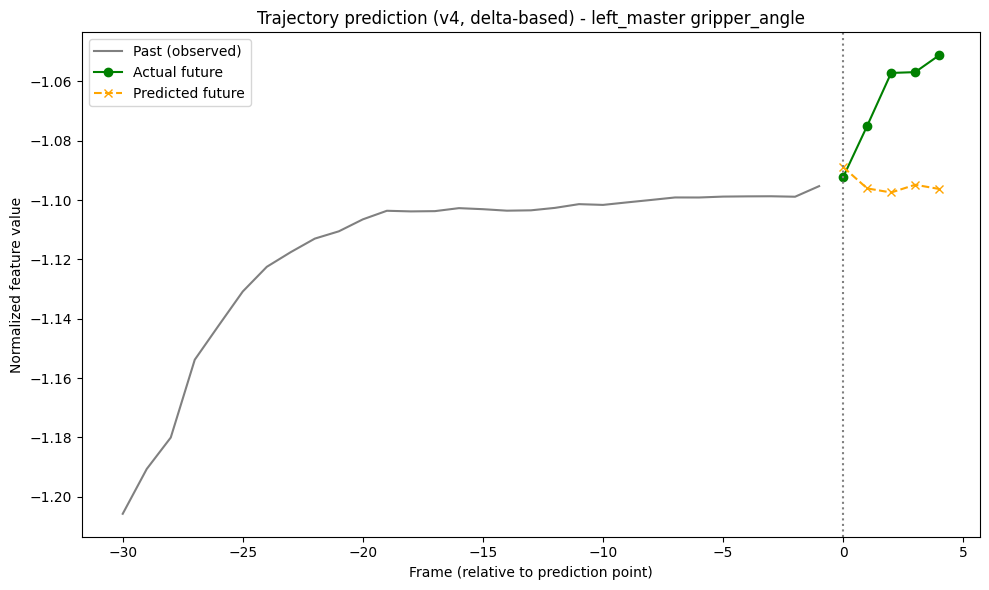

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import os

os.makedirs("results/plots", exist_ok=True)

sample_trial_id = val_idx[0]
sample_trial = trials[sample_trial_id]

kin_norm = (
    (sample_trial['kinematics_raw'] - traj_feature_mean)
    / traj_feature_std
).astype(np.float32)

start = 200

window = kin_norm[start : start + TRAJ_WINDOW_SIZE]
last_frame = window[-1]

actual_future = kin_norm[
    start + TRAJ_WINDOW_SIZE :
    start + TRAJ_WINDOW_SIZE + TRAJ_HORIZON
]

traj_model.eval()
with torch.no_grad():
    x = torch.from_numpy(window).unsqueeze(0).to(DEVICE)
    pred_delta = traj_model(x).cpu().numpy()[0]

predicted_future = last_frame[None, :] + pred_delta

feature_idx = 18
feature_name = "left_master gripper_angle"

past_vals = window[:, feature_idx]
actual_vals = actual_future[:, feature_idx]
pred_vals = predicted_future[:, feature_idx]

past_x = np.arange(-TRAJ_WINDOW_SIZE, 0)
future_x = np.arange(0, TRAJ_HORIZON)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(past_x, past_vals, color="gray", label="Past (observed)")
ax.plot(future_x, actual_vals, "o-", color="green", label="Actual future")
ax.plot(future_x, pred_vals, "x--", color="orange", label="Predicted future")
ax.axvline(0, color="gray", linestyle=":")
ax.set_title(f"Trajectory prediction (v4, delta-based) - {feature_name}")
ax.set_xlabel("Frame (relative to prediction point)")
ax.set_ylabel("Normalized feature value")
ax.legend()
fig.tight_layout()

save_path = "results/plots/trajectory_prediction_example.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

from google.colab import files
files.download(save_path)


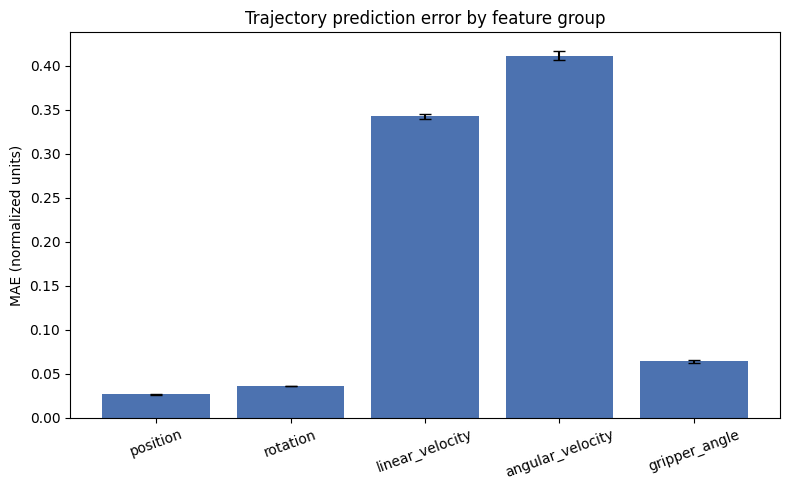

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
group_means = [model_feature_errors[:, :, group_to_indices[g]].mean() for g in group_names]
group_sems = [
    model_feature_errors[:, :, group_to_indices[g]].std(ddof=1) / np.sqrt(model_feature_errors[:, :, group_to_indices[g]].size)
    for g in group_names
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(group_names, group_means, yerr=group_sems, capsize=4, color="#4C72B0")
ax.set_ylabel("MAE (normalized units)")
ax.set_title("Trajectory prediction error by feature group")
plt.xticks(rotation=20)
plt.tight_layout()

save_path = "results/plots/mae_by_feature_group.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

files.download(save_path)


## 9. Interactive Gradio dashboard (optional, local use only)

Not deployed publicly due to JIGSAWS licensing — run this locally if you have your own dataset access. Used to record the demo video referenced in the README.

In [16]:
# pip install gradio -q
import gradio as gr

checkpoint = torch.load("/content/final_transformer_model.pt", map_location=DEVICE, weights_only=False)
dashboard_model = TransformerGesturePolicy(input_dim=76, d_model=128, nhead=4, num_layers=3,
                                            num_classes=NUM_CLASSES, dropout=0.3).to(DEVICE)
dashboard_model.load_state_dict(checkpoint["model_state_dict"])
dashboard_model.eval()

dash_feature_mean = checkpoint["feature_mean"]
dash_feature_std = checkpoint["feature_std"]
dash_idx_to_label = checkpoint["idx_to_label"]
WINDOW_SIZE = 30

trial_lookup = {t['trial_name']: t for t in trials}
trial_names = sorted(trial_lookup.keys())


def predict_at_frame(trial_name, frame_idx):
    trial = trial_lookup[trial_name]
    kin_raw = trial['kinematics_raw']
    labels = trial['labels']
    num_frames = kin_raw.shape[0]
    frame_idx = max(WINDOW_SIZE, min(int(frame_idx), num_frames - 1))

    window = kin_raw[frame_idx - WINDOW_SIZE:frame_idx]
    window_norm = ((window - dash_feature_mean) / dash_feature_std).astype(np.float32)
    x = torch.from_numpy(window_norm).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs = torch.softmax(dashboard_model(x), dim=1).cpu().numpy()[0]

    true_label = labels[frame_idx]
    top5_idx = np.argsort(probs)[::-1][:5]
    top5_labels = [dash_idx_to_label[i] for i in top5_idx]
    top5_probs = [probs[i] for i in top5_idx]
    predicted_label = top5_labels[0]

    fig, ax = plt.subplots(figsize=(6, 3.5))
    colors = ["#2ca02c" if lbl == true_label else "#1f77b4" for lbl in top5_labels]
    ax.barh(top5_labels[::-1], top5_probs[::-1], color=colors[::-1])
    ax.set_xlabel("Predicted probability")
    ax.set_xlim(0, 1)
    fig.tight_layout(pad=1.5)

    status = "Correct" if predicted_label == true_label else "Incorrect"
    summary = (f"**Trial:** {trial_name}  |  **Frame:** {frame_idx} / {num_frames}\n\n"
               f"**True gesture:** `{true_label}`\n\n"
               f"**Predicted next gesture:** `{predicted_label}` ({top5_probs[0]:.1%} confidence)\n\n"
               f"**Result:** {status}")
    return fig, summary


def update_slider_range(trial_name):
    num_frames = trial_lookup[trial_name]['kinematics_raw'].shape[0]
    return gr.update(minimum=WINDOW_SIZE, maximum=num_frames - 1, value=WINDOW_SIZE)


def play_tick(trial_name, frame_idx, step_size):
    num_frames = trial_lookup[trial_name]['kinematics_raw'].shape[0]
    new_idx = int(frame_idx) + int(step_size)
    if new_idx >= num_frames - 1:
        new_idx = WINDOW_SIZE
    fig, summary = predict_at_frame(trial_name, new_idx)
    return new_idx, fig, summary


with gr.Blocks(title="Surgical Gesture Prediction Dashboard") as demo:
    gr.Markdown("# Surgical Gesture Prediction Dashboard")
    gr.Markdown(
        "Select a trial, then press **Play** to watch the model's next-gesture "
        "prediction update live from kinematic data alone (no video shown, by design)."
    )

    with gr.Row():
        trial_dropdown = gr.Dropdown(choices=trial_names, value=trial_names[0], label="Select trial")
        frame_slider = gr.Slider(minimum=WINDOW_SIZE, maximum=200, value=WINDOW_SIZE, step=1, label="Frame index")

    with gr.Row():
        play_btn = gr.Button("Play")
        pause_btn = gr.Button("Pause")
        speed_slider = gr.Slider(minimum=1, maximum=10, value=2, step=1, label="Playback speed")

    prob_plot_output = gr.Plot(label="Top-5 predicted gestures")
    summary_output = gr.Markdown()
    playback_timer = gr.Timer(value=0.15, active=False)

    trial_dropdown.change(fn=update_slider_range, inputs=trial_dropdown, outputs=frame_slider)
    trial_dropdown.change(fn=predict_at_frame, inputs=[trial_dropdown, frame_slider],
                           outputs=[prob_plot_output, summary_output])
    frame_slider.change(fn=predict_at_frame, inputs=[trial_dropdown, frame_slider],
                         outputs=[prob_plot_output, summary_output])
    play_btn.click(fn=lambda: gr.Timer(active=True), outputs=playback_timer)
    pause_btn.click(fn=lambda: gr.Timer(active=False), outputs=playback_timer)
    playback_timer.tick(fn=play_tick, inputs=[trial_dropdown, frame_slider, speed_slider],
                         outputs=[frame_slider, prob_plot_output, summary_output])

demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://667eccfb9cbdcd70f0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
